# MACHINE LEARNING ASSIGNMENT: Customer Segmentation and Purchase Prediction
Name: Chetna Mahajan
Date: 24-01-2026

## Part 1: Data Exploration and pre-processing

In [1]:
### 1.1 Load & inspect-

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import seaborn as sns

# Load the dataset using pandas
customer_data= pd.read_csv('data/customer_data.csv')

In [2]:
# Display the first 10 rows
customer_data.head(10)

,customer_id,age,gender,city_tier,membership_type,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
0,CUST000878,29.0,Female,Tier 3,Silver,465.00,11,42.27,50.0,18.0,4,15.53,0
1,CUST004886,47.0,Male,Tier 1,Platinum,4451.32,23,193.54,16.0,38.0,6,404.45,1
2,CUST002485,37.0,Male,Tier 1,Platinum,1903.02,21,90.62,29.0,28.0,5,207.83,0
3,CUST002289,37.0,Male,Tier 1,Platinum,3952.75,23,171.86,33.0,31.0,11,502.30,1
4,CUST000812,25.0,Male,Tier 1,Silver,1367.07,11,124.28,46.0,18.0,7,70.93,0
5,CUST000249,36.0,Female,Tier 2,Silver,160.15,6,26.69,39.0,8.0,3,8.96,0
6,CUST003299,32.0,Male,Tier 2,Gold,3440.79,17,202.40,29.0,29.0,6,304.40,1
7,CUST000107,37.0,Female,Tier 1,Silver,505.17,6,84.20,51.0,15.0,4,16.93,0
8,CUST000280,26.0,Female,Tier 3,Silver,2476.96,9,275.22,44.0,10.0,4,71.01,0
9,CUST001282,27.0,NaN,Tier 1,Silver,404.24,12,33.69,56.0,17.0,8,26.07,0


In [3]:
# Check the shape of the dataset
customer_data.shape

(5025, 13)

In [4]:
# Display data types and check for null values using info
customer_data.dtypes

customer_id                      object
age                             float64
gender                           object
city_tier                        object
membership_type                  object
total_spend                     float64
num_transactions                  int64
avg_transaction_value           float64
days_since_last_purchase        float64
num_visits                      float64
product_categories_purchased      int64
discount_used                   float64
high_value_customer               int64
dtype: object

In [5]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   5025 non-null   object 
 1   age                           4723 non-null   float64
 2   gender                        4724 non-null   object 
 3   city_tier                     5025 non-null   object 
 4   membership_type               5025 non-null   object 
 5   total_spend                   5025 non-null   float64
 6   num_transactions              5025 non-null   int64  
 7   avg_transaction_value         5025 non-null   float64
 8   days_since_last_purchase      4723 non-null   float64
 9   num_visits                    4724 non-null   float64
 10  product_categories_purchased  5025 non-null   int64  
 11  discount_used                 5025 non-null   float64
 12  high_value_customer           5025 non-null   int64  
dtypes: 

In [6]:
# Generate summary statistics using describe
customer_data.describe()

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
count,4723.000000,5025.000000,5025.000000,5025.000000,4723.000000,4724.000000,5025.000000,5025.000000,5025.000000
mean,39.279483,3520.270324,15.047761,219.407385,29.456490,23.032599,6.714030,308.958681,0.373731
std,11.608329,3503.705187,7.628706,167.171094,13.163085,10.362527,3.162972,373.824281,0.483842
min,18.000000,11.590000,1.000000,1.770000,4.000000,3.000000,1.000000,0.430000,0.000000
25%,30.000000,1031.970000,9.000000,99.830000,19.000000,15.000000,4.000000,61.530000,0.000000
50%,38.000000,2258.380000,14.000000,176.020000,26.000000,21.000000,6.000000,166.820000,0.000000
75%,47.000000,4777.600000,20.000000,291.620000,41.000000,30.000000,9.000000,405.600000,1.000000
max,75.000000,27621.780000,43.000000,1500.110000,69.000000,59.000000,15.000000,3999.660000,1.000000


In [7]:
### 1.2 Handle Missing values

# Identify columns with missing values
missing_cols = pd.DataFrame({
    'Missing Count': customer_data.isnull().sum(),
    'Missing %': customer_data.isnull().sum() / len(customer_data) * 100
})

# sort by Missing % in descending order
missing_cols = missing_cols.sort_values(by='Missing %', ascending=False)

print(missing_cols)


                              Missing Count  Missing %
age                                     302    6.00995
days_since_last_purchase                302    6.00995
gender                                  301    5.99005
num_visits                              301    5.99005
customer_id                               0    0.00000
membership_type                           0    0.00000
city_tier                                 0    0.00000
num_transactions                          0    0.00000
total_spend                               0    0.00000
avg_transaction_value                     0    0.00000
product_categories_purchased              0    0.00000
discount_used                             0    0.00000
high_value_customer                       0    0.00000


In [8]:
# Fill numerical columns with median values
num_cols= customer_data.select_dtypes(include=['int64', 'float64']).columns
customer_data[num_cols]= customer_data[num_cols].fillna(customer_data[num_cols].median())

# Fill categorical columns with Mode
cat_cols= customer_data.select_dtypes(include=['object', 'category']).columns
for cols in cat_cols:
    customer_data[cols]= customer_data[cols].fillna(customer_data[cols].mode()[0])
    
# Verify that no missing value remains
print(customer_data.isnull().sum())

customer_id                     0
age                             0
gender                          0
city_tier                       0
membership_type                 0
total_spend                     0
num_transactions                0
avg_transaction_value           0
days_since_last_purchase        0
num_visits                      0
product_categories_purchased    0
discount_used                   0
high_value_customer             0
dtype: int64


In [9]:
### 1.3 Handle duplicates
# Check for duplicate rows based on customer_id
customer_data['customer_id'].duplicated().any()

np.True_

np.True_: There exists duplicate rows in customer_id

In [10]:
# Remove duplicate rows
duplicates_removed = customer_data.duplicated(subset='customer_id').sum()
customer_data = customer_data.drop_duplicates(subset='customer_id')

# Report the number of duplicates removed
print("Number of duplicate rows removed:", duplicates_removed)


Number of duplicate rows removed: 25


25 duplicate rows in customer_id are removed

In [11]:
### 1.4 Basic Exploratory Analysis
# Use value counts to show the distribution of : gender, membership_type and high_value_customer
def value_counts_table(col):
    return pd.DataFrame({
        'Count': customer_data[col].value_counts(),
        'Percentage (%)': customer_data[col].value_counts(normalize=True) * 100
    }).round(2)

value_counts_table('gender')

,Count,Percentage (%)
gender,,
Female,2639,52.78
Male,2292,45.84
Other,69,1.38


In [12]:
value_counts_table('membership_type')

,Count,Percentage (%)
membership_type,,
Silver,1959,39.18
Gold,1911,38.22
Platinum,1130,22.60


In [13]:
value_counts_table('high_value_customer')

,Count,Percentage (%)
high_value_customer,,
0,3129,62.58
1,1871,37.42


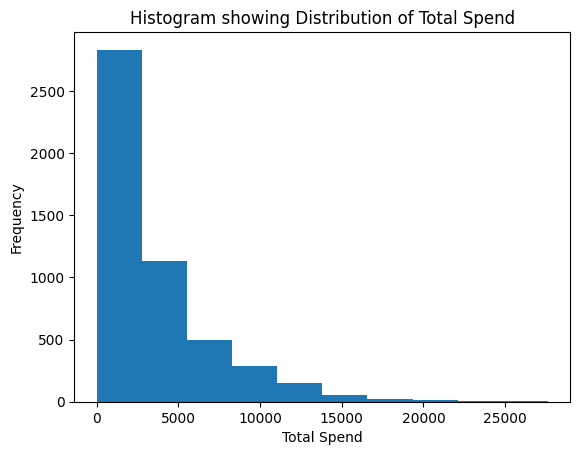

In [14]:
# Create 2 visualisations using seabormm or matplotlib
# Histogram showing distribution of total_spend
import matplotlib.pyplot as plt

plt.hist(customer_data['total_spend'].dropna(), bins=10)
plt.xlabel('Total Spend')
plt.ylabel('Frequency')
plt.title('Histogram showing Distribution of Total Spend')
plt.show()



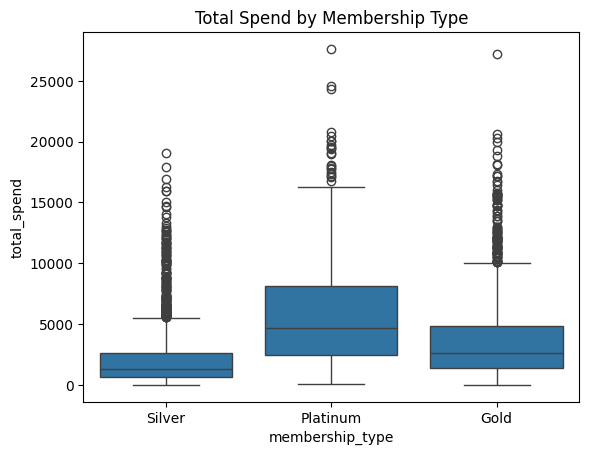

In [15]:
# Box plot comparing total_spend across different membership_types

plt.figure()
sns.boxplot(
    x='membership_type',
    y='total_spend',
    data=customer_data
)
plt.title('Total Spend by Membership Type')
plt.show()



The histogram shows a positive right skewed distribution of total spend which means most of the customers are low spenders in the range of 5000 whereas few customers are in the range of high spend which are high value or premium customers.
The Box plot shows that membership type is a strong predictor of total spend. The Platinum members have high median and variability followed by Gold and Silver membership. The outliers are also extreme in platinum members followed by Gold and Silver.
Hence it is important to scale the data before clusterring.

## PART 2: Customer Segmentation using clustering

In [16]:
### 2.1 Prepare data for Clustering
# Select numerical features for customer Segmentation
numerical_features= customer_data[['age', 'total_spend', 'num_transactions', 'avg_transaction_value', 'days_since_last_purchase', 'num_visits']]
print(numerical_features)

       age  total_spend  num_transactions  avg_transaction_value  \
0     29.0       465.00                11                  42.27   
1     47.0      4451.32                23                 193.54   
2     37.0      1903.02                21                  90.62   
3     37.0      3952.75                23                 171.86   
4     25.0      1367.07                11                 124.28   
...    ...          ...               ...                    ...   
5020  38.0     16708.59                22                 759.48   
5021  31.0       544.70                 5                 108.94   
5022  41.0      1438.83                12                 119.90   
5023  44.0      9543.98                32                 298.25   
5024  29.0       571.53                 9                  63.50   

      days_since_last_purchase  num_visits  
0                         50.0        18.0  
1                         16.0        38.0  
2                         29.0        28.0  
3  

In [17]:
# Apply standard scaling to normalise all selected features
scaler= StandardScaler()
num_scaled= scaler.fit_transform(numerical_features)
num_scaled

array([[-0.90631755, -0.8719261 , -0.52917369, -1.05984339,  1.62204464,
        -0.48757685],
       [ 0.69256475,  0.2655669 ,  1.04488915, -0.155375  , -1.03617339,
         1.50334537],
       [-0.19570319, -0.46158832,  0.78254534, -0.77075073, -0.01979591,
         0.50788426],
       ...,
       [ 0.15960398, -0.59404454, -0.39800179, -0.59568076, -0.25434456,
        -0.38803074],
       [ 0.42608437,  1.71875307,  2.22543628,  0.47070343, -0.56707609,
         2.00107592],
       [-0.90631755, -0.84152785, -0.7915175 , -0.9329057 ,  1.07476446,
        -1.08485352]], shape=(5000, 6))

. Standard Scaling is necessary before clustering to ensure all the features are at a equal distance from mean and contribute equally to distance calculations in clustering algorithms.

In [ ]:
### 2.2 Determine optimal number of clusters (k)
# Implement k-means clustering for k value ranging from 2-8

wcss=[]
for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(num_scaled)
    wcss.append(km.inertia_)


In [19]:
# calculating WCSS for each k value

for k, value in zip(range(2, 8), wcss):
    print(f"k = {k}, WCSS = {value}")


k = 2, WCSS = 16570.382094922606
k = 3, WCSS = 11729.474687073407
k = 4, WCSS = 9809.301713018092
k = 5, WCSS = 8606.708493235723
k = 6, WCSS = 8014.113992576807
k = 7, WCSS = 7513.319808228755


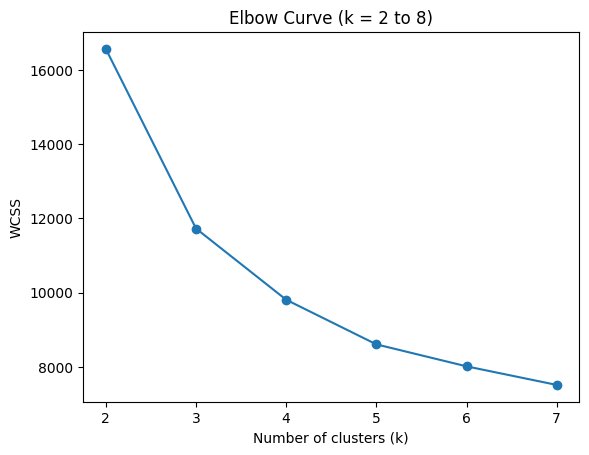

In [20]:
# ELBOW plot curve WCSS v/s No. of Clusters

plt.plot(range(2, 8), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Curve (k = 2 to 8)')
plt.show()


. The WCSS decreases sharply till k= 4 and then it started to flatten showing that the results are diminishing beyond this point. Hence choosen k=4

In [ ]:
### 2.3 Apply k-means and Profile Segments
# Apply k-means clusterring with k=4
optimal_k= 4
numerical_features= numerical_features.copy()
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
numerical_features["Cluster"] = kmeans.fit_predict(num_scaled)
numerical_features.head()

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,Cluster
0,29.0,465.00,11,42.27,50.0,18.0,1
1,47.0,4451.32,23,193.54,16.0,38.0,2
2,37.0,1903.02,21,90.62,29.0,28.0,0
3,37.0,3952.75,23,171.86,33.0,31.0,0
4,25.0,1367.07,11,124.28,46.0,18.0,1


In [22]:
# Add cluster label as new column 'customer_segment' in the original dataframe

customer_data['Customer_segment'] = numerical_features['Cluster']
customer_data.head()

,customer_id,age,gender,city_tier,membership_type,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer,Customer_segment
0,CUST000878,29.0,Female,Tier 3,Silver,465.00,11,42.27,50.0,18.0,4,15.53,0,1
1,CUST004886,47.0,Male,Tier 1,Platinum,4451.32,23,193.54,16.0,38.0,6,404.45,1,2
2,CUST002485,37.0,Male,Tier 1,Platinum,1903.02,21,90.62,29.0,28.0,5,207.83,0,0
3,CUST002289,37.0,Male,Tier 1,Platinum,3952.75,23,171.86,33.0,31.0,11,502.30,1,0
4,CUST000812,25.0,Male,Tier 1,Silver,1367.07,11,124.28,46.0,18.0,7,70.93,0,1


In [23]:
# Display the count of customers in each cluster
cluster_counts = (
    numerical_features['Cluster']
    .value_counts()
    .reset_index()
)

cluster_counts.columns = ['Cluster', 'Customer_Count']
cluster_counts

,Cluster,Customer_Count
0,0,1947
1,1,1742
2,2,816
3,3,495


In [24]:
# Calculate the mean value of key features for each cluster using groupby

cluster_summary = numerical_features.groupby('Cluster').mean()
cluster_summary


,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits
Cluster,,,,,,
0,41.487930,2829.547149,14.852594,202.212537,24.506934,22.626091
1,28.504018,997.751871,7.960964,145.085121,43.936280,13.541332
2,50.495098,5814.068358,26.519608,221.914522,16.615196,37.772059
3,49.254545,11336.849354,21.707071,545.660606,17.082828,32.375758


  Cluster 0 represents low spending customers with lower average income.
  Cluster 1 represents low spending customers with lower number of transactions, average transaction value and less number of visits.
  Cluster 2 represents moderate spending customers with high engagement in num_visits and number of transactions.
  Cluster 3 represents premium customers with high total spend. 

PART 3: Predictive Modeling

In [25]:
### 3.1 Feature Engineering
numerical_features['spend_per_visit']= (numerical_features['total_spend']/ numerical_features['num_visits']).replace(0, np.nan)

numerical_features['discount_percentage']= (customer_data['discount_used']/ numerical_features['total_spend']).replace(0, np.nan)

numerical_features.head()

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,Cluster,spend_per_visit,discount_percentage
0,29.0,465.00,11,42.27,50.0,18.0,1,25.833333,0.033398
1,47.0,4451.32,23,193.54,16.0,38.0,2,117.140000,0.090861
2,37.0,1903.02,21,90.62,29.0,28.0,0,67.965000,0.109211
3,37.0,3952.75,23,171.86,33.0,31.0,0,127.508065,0.127076
4,25.0,1367.07,11,124.28,46.0,18.0,1,75.948333,0.051885


- Adding two new feaures 'spend_per_visit' and 'discount_percentage' will help us to understand customer behaviour. 
'spend_per_visit' will tell us how the customer spends- high spend in few visits or low spend but multiple visits.
'discount_percentage' will tell us whether a customer buys because of discounts or irrespective of discounts. Helps to identify discount driven customers and loyal/ ready to pay full price customers.


In [26]:
## 3.2 Data preparation for modeling
X= customer_data.drop(columns= ['high_value_customer', 'customer_id'])
Y= customer_data['high_value_customer']
print("Feature matrix shape:", X.shape)
print("Target vector shape :", Y.shape)


Feature matrix shape: (5000, 12)
Target vector shape : (5000,)


In [27]:
# Split the data into training(80%) and test(20%) sets with random_state= 42
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state= 42, stratify=Y
)

In [28]:
# Applying One Hot Encoding to categorical features- gender, city_tier, membership_type

categorical_features= ['gender', 'city_tier', 'membership_type']
enco= OneHotEncoder(sparse_output= False)

X_train_enco= enco.fit_transform(X_train[categorical_features])
X_test_enco= enco.transform(X_test[categorical_features])

X_train_encoded_df = pd.DataFrame(
    X_train_enco,
    columns=enco.get_feature_names_out(categorical_features),
    index=X_train.index
)
X_test_encoded_df= pd.DataFrame(
    X_test_enco,
    columns=enco.get_feature_names_out(categorical_features),
    index= X_test.index
)
X_train_encoded_df.columns
X_test_encoded_df.columns


Index(['gender_Female', 'gender_Male', 'gender_Other', 'city_tier_Tier 1',
       'city_tier_Tier 2', 'city_tier_Tier 3', 'membership_type_Gold',
       'membership_type_Platinum', 'membership_type_Silver'],
      dtype='object')

In [29]:
# apply standard scaling to numerical features in training data to avoid data leakage
numerical_features = X_train.drop(columns=categorical_features).columns.tolist()  # no need to scale cat features as they are in 0 & 1

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numerical_features])
X_test_scaled = scaler.transform(X_test[numerical_features])

In [ ]:
## 3.3 Build model
# Build Classification model 
ml_model = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42)
}

In [31]:
# Fit the model on training data

for name, model in ml_model.items():
    model.fit(X_train_scaled, Y_train)
    print(f"{name} trained successfully")


Logistic Regression trained successfully


In [32]:
# Generate predictions on test data
for name, model in ml_model.items():
    Y_pred= model.predict(X_test_scaled)


* I have chosen Logistic Regression as Logistic Regression is best where output is either 0 or 1 and here the target variable is high_value_customer which is either Yes/No and in Binary its 0 or 1


In [33]:
## 3.4 Model Evaluation

metrix_table=[]
for name, model in ml_model.items():
    cm = confusion_matrix(Y_test, Y_pred)
    acc = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred, pos_label=1)
    rec = recall_score(Y_test, Y_pred, pos_label=1)
    f1 = f1_score(Y_test, Y_pred, pos_label=1)

    metrix_table.append({
        "Model": name,
        "Confusion Metrix": cm,
        "Accuracy"        : acc,
        "Precision"       : prec,
        "Recall"          : rec,
        "F1"              : f1
    })

print(
    f"Confusion Matrix:\n{cm}\n"
    f"Accuracy:   {acc}\n"
    f"Precision:  {prec}\n"
    f"Recall:     {rec}\n"
    f"F1 Score:   {f1}"
)


Confusion Matrix:
[[615  11]
 [ 21 353]]
Accuracy:   0.968
Precision:  0.9697802197802198
Recall:     0.9438502673796791
F1 Score:   0.9566395663956639


In [34]:
# Classification report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       626
           1       0.97      0.94      0.96       374

    accuracy                           0.97      1000
   macro avg       0.97      0.96      0.97      1000
weighted avg       0.97      0.97      0.97      1000



### PART 4- Optimisation and Insights

In [35]:
## 4.1 Hyperparameter Tuning
param_grid = {
    'C': [0.01, 0.1, 1],
    'l1_ratio': [0, 1],
    'solver': ['saga']
}

In [36]:
# Gridsearchcv with 3 fold cross-validation (cv=3)

lr = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv= 3,
    scoring= 'accuracy'
)
grid.fit(X_train_scaled, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'l1_ratio': [0, 1], 'solver': ['saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

In [ ]:
# Report the best parameters found
best_model = grid.best_estimator_
print(best_model)

LogisticRegression(C=1, l1_ratio=1, max_iter=1000, solver='saga')


In [38]:
best_model.fit(X_train_scaled, Y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [39]:
# Evaluate the tuned model on test data
Y_pred_new= best_model.predict(X_test_scaled)

In [40]:
# Performance metrix after tuning
print(classification_report(Y_test, Y_pred_new))


              precision    recall  f1-score   support

           0       0.97      0.98      0.98       626
           1       0.97      0.95      0.96       374

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [41]:
# Performance Comparison before and after tuning



In [42]:
## 4.2 Feature Importance Analysis

In [43]:
## 4.3 Business Recommendations